In [61]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from ast import literal_eval

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:literal_eval(x) if pd.notna(x) else x)

#Date Frame for Data Analyst in United States
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')]
df_DA_US = df_DA_US.dropna(subset="salary_year_avg")

In [62]:
df_DA_US = df_DA_US.explode('job_skills')
df_DA_US_group = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['median','count'])
df_DA_US_top_pay = df_DA_US_group.sort_values(by='median',ascending=False).head(10)
df_DA_US_top_skills = df_DA_US_group.sort_values(by='count',ascending=False).head(10).sort_values(by='median',ascending=False).head(10)


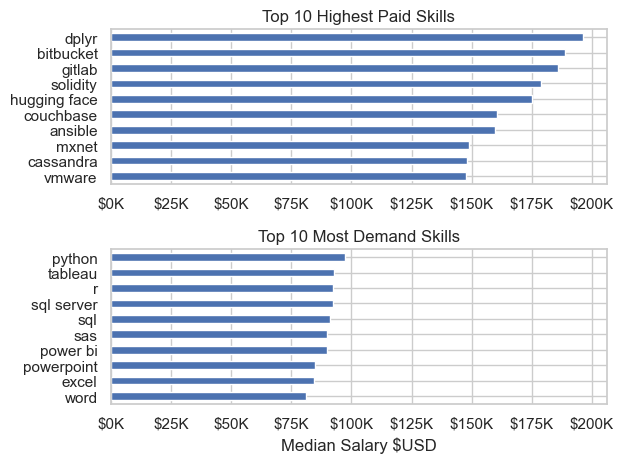

In [63]:
fig,ax = plt.subplots(2,1)
df_DA_US_top_pay.plot(kind='barh',y='median',ax=ax[0],legend = False)
ax[0].set_title('Top 10 Highest Paid Skills')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].invert_yaxis()
ax[0].xaxis.set_major_formatter(plt.FuncFormatter (lambda x,pos : f'${int(x/1000)}K'))

df_DA_US_top_skills[::-1].plot(kind='barh',y='median',ax=ax[1],legend = False)
ax[1].set_title('Top 10 Most Demand Skills')
ax[1].set_xlabel('Median Salary $USD')
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].set_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter (lambda x,pos : f'${int(x/1000)}K'))
fig.tight_layout()

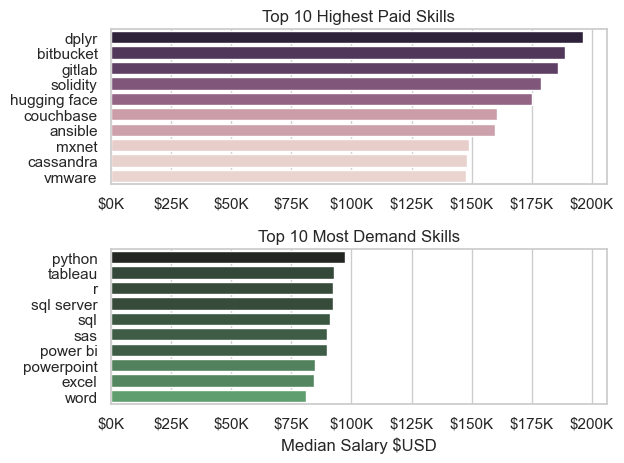

In [64]:
import seaborn as sns
#sns.color_palette("Spectral", as_cmap=True)
sns.set_theme(style="whitegrid")
fig,ax = plt.subplots(2,1)
sns.barplot(data=df_DA_US_top_pay, x='median', y='job_skills' ,ax=ax[0],hue='median',legend=False)
ax[0].set_title('Top 10 Highest Paid Skills')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter (lambda x,pos : f'${int(x/1000)}K'))


sns.barplot(data=df_DA_US_top_skills, x='median', y=df_DA_US_top_skills.index ,ax=ax[1],hue='median',palette='dark:g_r',legend=False)
ax[1].set_title('Top 10 Most Demand Skills')
ax[1].set_xlabel('Median Salary $USD')
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].set_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter (lambda x,pos : f'${int(x/1000)}K'))
fig.tight_layout()


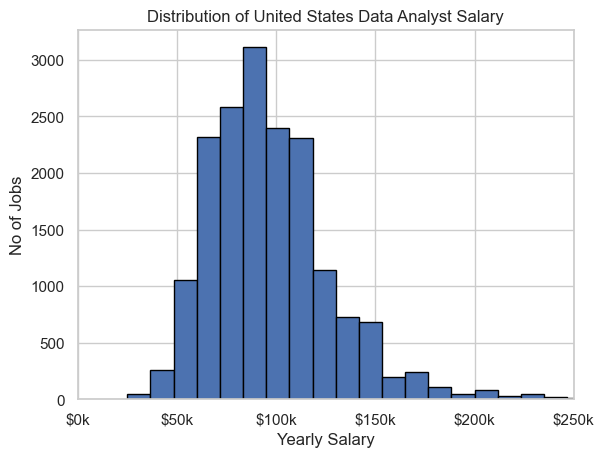

In [65]:
df_DA_US['salary_year_avg'].plot(kind='hist',bins=30,edgecolor = 'black')
plt.xlim(0,250000)
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,index: f'${int(x/1000)}k'))
plt.title('Distribution of United States Data Analyst Salary')
plt.xlabel('Yearly Salary')
plt.ylabel('No of Jobs')
plt.show()

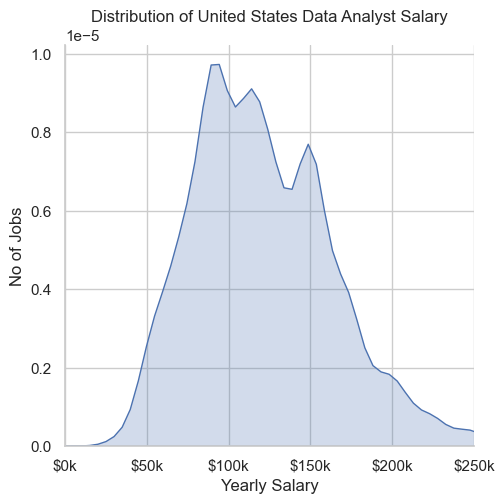

In [66]:
sns.displot(df['salary_year_avg'],kind='kde',fill=True)
plt.xlim(0,250000)
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,index: f'${int(x/1000)}k'))
plt.title('Distribution of United States Data Analyst Salary')
plt.xlabel('Yearly Salary')
plt.ylabel('No of Jobs')
plt.show()

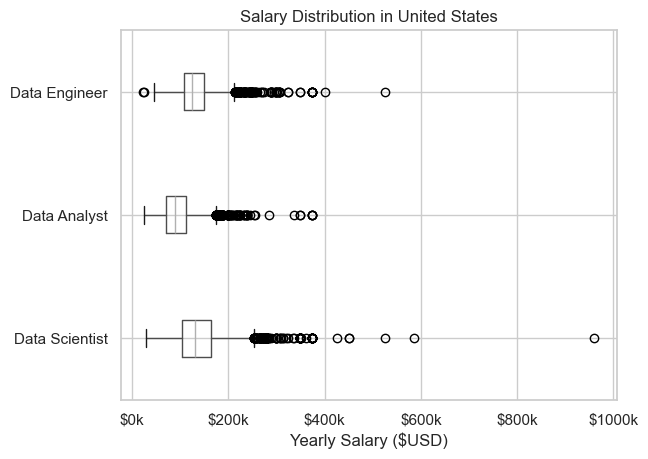

In [83]:
titles=['Data Scientist','Data Analyst','Data Engineer']
df_US_box = df[(df['job_title_short'].isin(titles)) & (df['job_country'] == 'United States')].copy()
df_US_box = df_US_box.dropna(subset='salary_year_avg')
job_list = [df_US_box[df_US_box['job_title_short'] == title]['salary_year_avg'] for title in titles]


df_box = pd.DataFrame(job_list, index=titles,).T
df_box.boxplot(vert=False)
plt.title('Salary Distribution in United States')
plt.xlabel('Yearly Salary ($USD)')
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter (lambda x,pos:f'${int(x/1000)}k'))

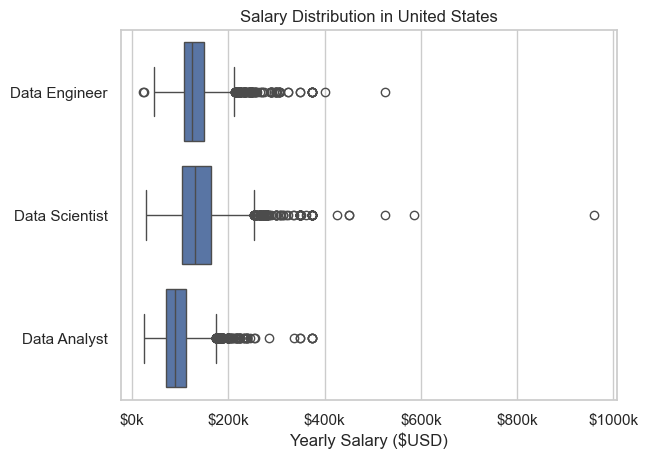

In [84]:
sns.boxplot(data=df_US_box, x='salary_year_avg', y='job_title_short', vert=False)
plt.title('Salary Distribution in United States')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('')
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter (lambda x,pos:f'${int(x/1000)}k'))